In [3]:
# Sem regras
from ultralytics import RTDETR
import cv2
import matplotlib.pyplot as plt

def testar_modelo_centros(img_path, weights_path, conf_threshold=0.1, iou=0.1):
    # 1. Carregar o modelo
    model = RTDETR(weights_path)

    # 2. Realizar a predição
    results = model.predict(source=img_path, conf=conf_threshold, device='cuda')[0]

    # 3. Pegar a imagem original
    img_desenho = results.orig_img.copy()

    # 4. Extrair e ORDENAR as caixas da esquerda para a direita (pelo x1)
    boxes = results.boxes.xyxy.cpu().numpy()
    boxes = boxes[boxes[:, 0].argsort()]
    
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box) # Convertendo para int para o OpenCV
        
        # cv2.rectangle(img_desenho, (x1, y1), (x2, y2), (255, 100, 0), 2)
        
        # Calcular o centro
        center_x = int((x1 + x2) / 2)
        center_y = int((y1 + y2) / 2)
        
        # 5. Desenhar a bola vermelha (tamanho 12)
        cv2.circle(img_desenho, (center_x, center_y), 12, (0, 0, 255), -1)
        
        # 6. Escrever o número DENTRO da bola
        texto = str(i + 1)
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.4
        thickness = 1
        
        text_size = cv2.getTextSize(texto, font, font_scale, thickness)[0]
        text_x = center_x - text_size[0] // 2
        text_y = center_y + text_size[1] // 2
        
        # Print para conferência
        print(f"Biscoito {texto}: Caixa[{x1}, {y1}, {x2}, {y2}] Centro[{center_x}, {center_y}]")
        cv2.putText(img_desenho, texto, (text_x, text_y), font, 
                    font_scale, (255, 255, 255), thickness, cv2.LINE_AA)

    # 7. Converter e exibir
    img_rgb = cv2.cvtColor(img_desenho, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(15, 10))
    plt.imshow(img_rgb)
    plt.title(f"Detecção Completa: {len(boxes)} Biscoitos", fontsize=16)
    plt.axis('off')
    plt.show()

    return len(boxes)

In [4]:
from ultralytics import RTDETR
import cv2
import matplotlib.pyplot as plt
import numpy as np

def testar_modelo_centros_1280(img_path, weights_path, conf_threshold=0.1, iou_threshold=0.1):
    # 1. Carregar o modelo
    model = RTDETR(weights_path)

    # 2. Predição com 1280px e NMS
    results = model.predict(
        source=img_path, 
        conf=conf_threshold, 
        iou=iou_threshold, 
        imgsz=1280, 
        device='cuda'
    )[0]
    nomes_das_classes = results.names

    img_desenho = results.orig_img.copy()

    # 3. Extrair coordenadas E scores
    boxes = results.boxes.xyxy.cpu().numpy()
    scores = results.boxes.conf.cpu().numpy()
    classes = results.boxes.cls.cpu().numpy()

    if len(boxes) == 0:
        print("Nenhum biscoito detectado.")
        return 0

    # 4. Combinar boxes e scores para ordenar mantendo a relação
    # Criamos uma matriz onde a última coluna é o score
    deteccoes = np.column_stack((boxes, scores, classes))
    
    # Ordenar da esquerda para a direita pelo x1 (coluna 0)
    deteccoes = deteccoes[deteccoes[:, 0].argsort()]
    
    print(f"\n--- Relatório de Detecção (1280px | IoU: {iou_threshold}) ---")

    for i, det in enumerate(deteccoes):
        x1, y1, x2, y2 = map(int, det[:4])
        id_classe = int(det[5])
        nome_classe = nomes_das_classes[id_classe]
        score = det[4]
        
        center_x = int((x1 + x2) / 2)
        center_y = int((y1 + y2) / 2)
        
        # 5. Desenhar o centro (bola vermelha)
        cv2.circle(img_desenho, (center_x, center_y), 12, (0, 0, 255), -1)
        
        # 6. Texto: Número e Score
        id_texto = str(i + 1)
        score_texto = f"{score:.2f}" # Formata o score com 2 casas decimais
        
        font = cv2.FONT_HERSHEY_SIMPLEX
        
        # Desenhar o ID dentro da bola
        text_size = cv2.getTextSize(id_texto, font, 0.4, 1)[0]
        cv2.putText(img_desenho, id_texto, 
                    (center_x - text_size[0] // 2, center_y + text_size[1] // 2), 
                    font, 0.4, (255, 255, 255), 1, cv2.LINE_AA)
        
        # Print detalhado no console
        print(f"Biscoito {id_texto}: Score: {score_texto} | Caixa: [{x1}, {y1}, {x2}, {y2}] | Centro: [{center_x}, {center_y}]")

    # 7. Exibição
    img_rgb = cv2.cvtColor(img_desenho, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(20, 12))
    plt.imshow(img_rgb)
    plt.title(f"RT-DETR-L 1280px | Total: {len(deteccoes)} | IoU Threshold: {iou_threshold}", fontsize=15)
    plt.axis('off')
    plt.show()

    return len(deteccoes)


image 1/1 D:\Arquivos\ProjetosPython\PICOS\data\outputs\teste_20260106_1280\SM\SM_14_direito__20260106_130353.jpg: 1280x1280 41 Biscoitos, 3 BiscoitoSaltados, 312.8ms
Speed: 8.3ms preprocess, 312.8ms inference, 1.5ms postprocess per image at shape (1, 3, 1280, 1280)
Biscoito 1: Caixa[0, 1, 24, 57] Centro[12, 29]
Biscoito 2: Caixa[0, 209, 12, 469] Centro[6, 339]
Biscoito 3: Caixa[0, 15, 16, 448] Centro[8, 231]
Biscoito 4: Caixa[10, 203, 35, 471] Centro[22, 337]
Biscoito 5: Caixa[11, 203, 36, 471] Centro[23, 337]
Biscoito 6: Caixa[11, 201, 34, 475] Centro[22, 338]
Biscoito 7: Caixa[12, 205, 38, 475] Centro[25, 340]
Biscoito 8: Caixa[33, 203, 56, 471] Centro[44, 337]
Biscoito 9: Caixa[53, 204, 76, 472] Centro[64, 338]
Biscoito 10: Caixa[53, 203, 87, 469] Centro[70, 336]
Biscoito 11: Caixa[73, 203, 96, 469] Centro[84, 336]
Biscoito 12: Caixa[92, 206, 116, 469] Centro[104, 337]
Biscoito 13: Caixa[110, 204, 135, 472] Centro[122, 338]
Biscoito 14: Caixa[110, 204, 135, 472] Centro[122, 338]
B

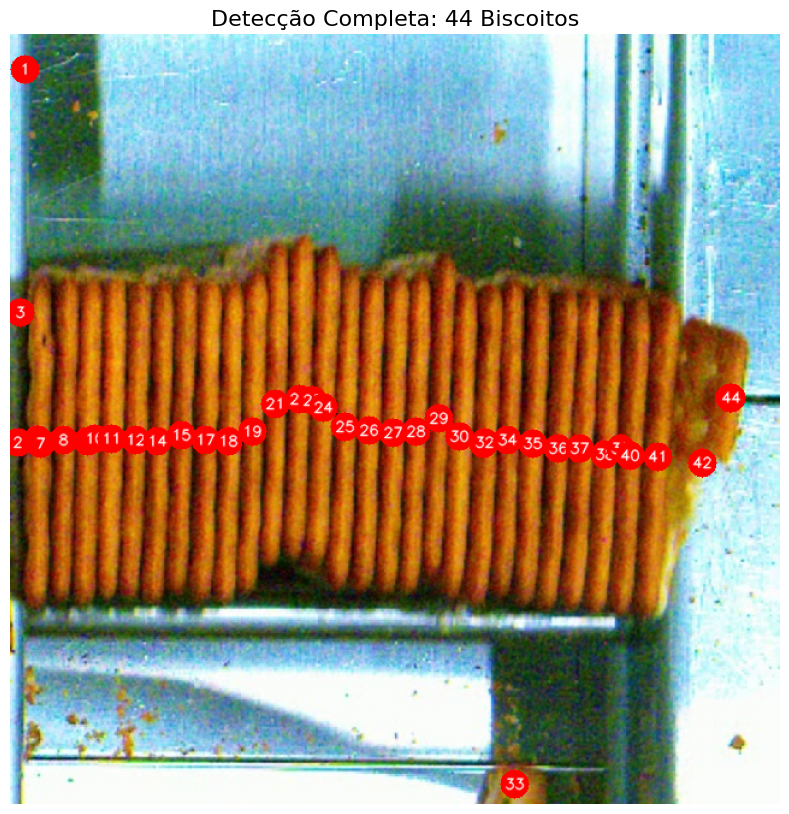

In [286]:
# --- Exemplo de Uso ---
caminho_pesos = r"D:\Arquivos\ProjetosPython\PICOS\data\inputs\ia_models\RTDETR\best_1280_x.pt"
caminho_imagem = r"D:\Arquivos\ProjetosPython\PICOS\data\outputs\teste_20260106_1280\SM\SM_14_direito__20260106_130353.jpg"

total = testar_modelo_centros(caminho_imagem, caminho_pesos)


image 1/1 D:\Arquivos\ProjetosPython\PICOS\data\outputs\teste_20260106_1280\SM\SM_14_direito__20260106_130353.jpg: 1280x1280 41 Biscoitos, 3 BiscoitoSaltados, 305.5ms
Speed: 7.1ms preprocess, 305.5ms inference, 0.7ms postprocess per image at shape (1, 3, 1280, 1280)

--- Relatório de Detecção (1280px | IoU: 0.1) ---
Biscoito
Biscoito 1: Score: 0.11 | Caixa: [0, 1, 24, 57] | Centro: [12, 29]
Biscoito
Biscoito 2: Score: 0.28 | Caixa: [0, 209, 12, 469] | Centro: [6, 339]
Biscoito
Biscoito 3: Score: 0.10 | Caixa: [0, 15, 16, 448] | Centro: [8, 231]
Biscoito
Biscoito 4: Score: 0.14 | Caixa: [10, 203, 35, 471] | Centro: [22, 337]
Biscoito
Biscoito 5: Score: 0.13 | Caixa: [11, 203, 36, 471] | Centro: [23, 337]
Biscoito
Biscoito 6: Score: 0.86 | Caixa: [11, 201, 34, 475] | Centro: [22, 338]
Biscoito
Biscoito 7: Score: 0.18 | Caixa: [12, 205, 38, 475] | Centro: [25, 340]
Biscoito
Biscoito 8: Score: 0.86 | Caixa: [33, 203, 56, 471] | Centro: [44, 337]
Biscoito
Biscoito 9: Score: 0.86 | Caixa: [

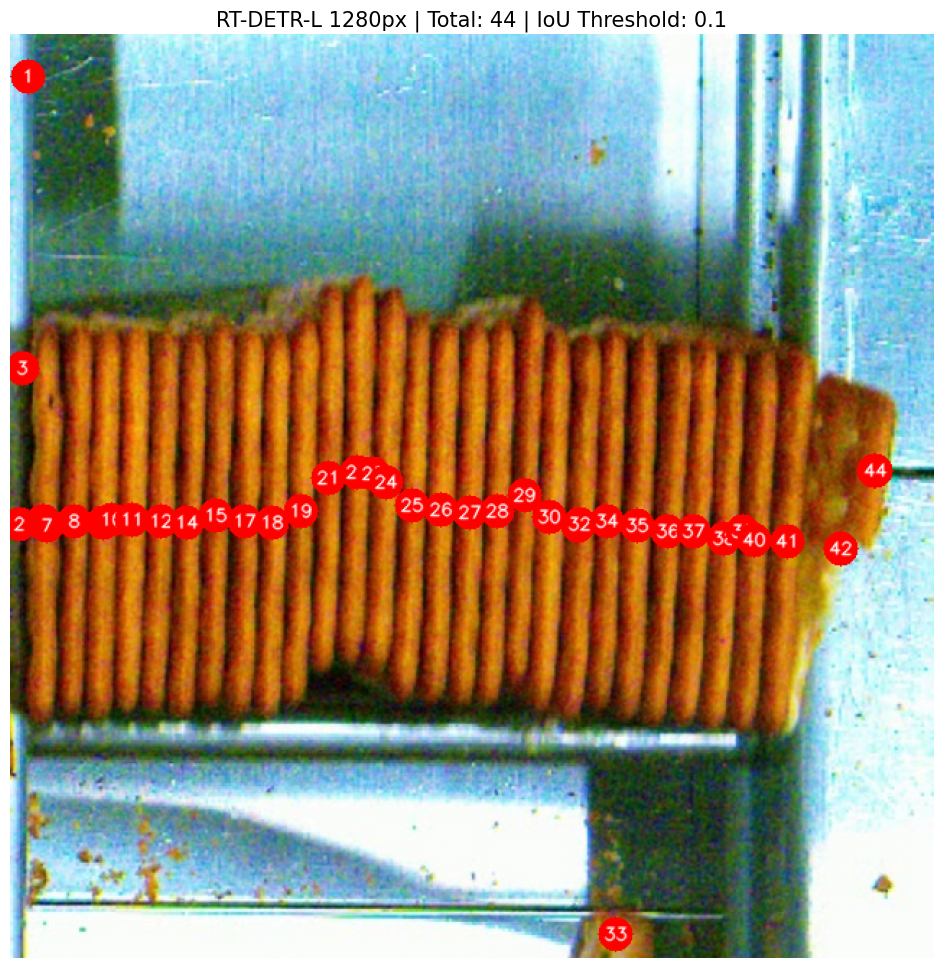

In [287]:
# --- Exemplo de Uso ---
caminho_pesos = r"D:\Arquivos\ProjetosPython\PICOS\data\inputs\ia_models\RTDETR\best_1280_x.pt"
caminho_imagem = r"D:\Arquivos\ProjetosPython\PICOS\data\outputs\teste_20260106_1280\SM\SM_14_direito__20260106_130353.jpg"

total = testar_modelo_centros_1280(caminho_imagem, caminho_pesos)

In [5]:
model_path = r"D:\Arquivos\ProjetosPython\PICOS\data\inputs\ia_models\RTDETR\best_20260105.pt"
torch_device = 'cuda'
model = RTDETR(model_path)
model.to(torch_device)

model.eval()

frame = r"D:\Arquivos\ProjetosPython\PICOS\data\outputs\teste_20260106\SM\SM_14_direito__20260106_011416.jpg"
results = model.predict(source=frame, conf=0.1, device='cuda')
detections = results[0].boxes  # Obter as detecções

# Extrair boxes e scores em um único loop
detections_info = [(detection.xyxy[0].tolist(), float(detection.conf)) for detection in detections]

boxes, scores = (zip(*detections_info) if detections_info else ([], []))  # Separar os boxes e scores em variáveis distintas

detections = []  # Cria uma lista para armazenar as detecções

# Itera sobre as caixas e pontuações para criar pares (box, score)
for box, score in zip(boxes, scores):
    detections.append([box, score])  # Não é necessário usar box.tolist() aqui

# Ordena as detecções pelo valor de x_min
detections_sorted = sorted(detections, key=lambda det: det[0][0])  # Ordena pelo x_min

print(len(detections_sorted))


image 1/1 D:\Arquivos\ProjetosPython\PICOS\data\outputs\teste_20260106\SM\SM_14_direito__20260106_011416.jpg: 640x640 28 Biscoitos, 65.5ms
Speed: 1.6ms preprocess, 65.5ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
28


In [ ]:
# Com regras
from ultralytics import RTDETR
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as transforms

def load_model(weights_path):
    model = RTDETR(weights_path)

def rules_detection(frame, detections_sorted, perc_top, perc_bottom, perc_median, min_score, limit_center):
    def median_calculate(detections_sorted, min_score, height, perc_median):
        all_centers = ([])  # Lista para armazenar as coordenadas y dos centros detectados
        for idx, detection in enumerate(detections_sorted):
            score = detection[1]   # Pontuação de confiança
            x_min, y_min, x_max, y_max = detection[0]  # Coordenadas da caixa - y cresce de cima para baixo

            # Verificar se a pontuação é maior que o limite e se está entre as linhas de contagem
            if (score > min_score and y_max > line_limit_top and y_min < line_limit_bottom):
                center_y = (y_min + y_max) // 2   # Calcular o centro da caixa de detecção
                all_centers.append(center_y)  # Adiciona y à lista de centros

        if all_centers:
            median_y = int(np.median(all_centers))  # Obtém a mediana
            line_bottom_median = int(median_y + int((height * perc_median) / 2))
            line_top_median = int(median_y - int((height * perc_median) / 2))
            
            cv2.line(
                frame, 
                (640, median_y), 
                (640 + 640, median_y), 
                (255, 0, 0), 
                2,
            )  # Desenhar a linha horizontal na moda

            return all_centers, median_y, line_top_median, line_bottom_median
        
        return None, None, None, None

    def regra_biscoito_saltado(valid_detections, no_valid_centers):
        """Tira possíveis duplicidades no biscoito saltado.
        1 - Pega a mediana da área
        2 - Verifica se algum box tem mais de um centro dentro dele
        3 - Caso tenha algum em 2, verifica se a área é maior que duas vezes a área mediana (possível biscoito saltado)
        4 - Caso 3 seja verdade, considera apenas um desses centros
        5 - Caso tudo acima seja verdade, também precisa ter pelo menos 50% de intersecção entre os boxes
        """
        final_detections = []
        valid_centers = []
        valid_boxes = []
    
        # 1. Primeiro, calculamos as áreas de todas as detecções candidatas
        areas = []
        for detection in valid_detections:
            x_min, y_min, x_max, y_max = detection[0]
            areas.append((x_max - x_min) * (y_max - y_min))

        if not areas:
            return [], [], []

        # 2. Encontramos a área mediana do frame atual
        area_mediana = np.median(areas)

        # 3. Filtragem com a nova regra de área
        for idx, detection in enumerate(valid_detections):
            x_min, y_min, x_max, y_max = detection[0]
            coords = detection[0]
            
            area_atual = (x_max - x_min) * (y_max - y_min)
            center_x = int((x_min + x_max) // 2)
            center_y = int((y_min + y_max) // 2)
                
            # is_too_large = area_atual > (area_mediana * 2.0) # Retirar por enquanto
            is_too_large = 1
            
            is_duplicate = False
            for f_det in final_detections:
                fx1, fy1, fx2, fy2 = f_det[0]
                
                # 1. Teste do Centro (sua regra anterior)
                is_inside = (fx1 <= center_x <= fx2 and fy1 <= center_y <= fy2)
                
                # 2. Teste de Intersecção (Área 0.5)
                # Calcula as coordenadas do retângulo de intersecção
                inter_x1 = max(x_min, fx1)
                inter_y1 = max(y_min, fy1)
                inter_x2 = min(x_max, fx2)
                inter_y2 = min(y_max, fy2)
                
                inter_w = max(0, inter_x2 - inter_x1)
                inter_h = max(0, inter_y2 - inter_y1)
                inter_area = inter_w * inter_h
                
                # Verifica se a intersecção ocupa mais de 50% da área de qualquer um dos dois boxes
                area_f = (fx2 - fx1) * (fy2 - fy1)
                overlap_ratio = inter_area / min(area_atual, area_f)
                
                if is_inside or overlap_ratio > 0.5:
                    is_duplicate = True
                    break
            
            if is_too_large:
                if not is_duplicate:
                    valid_centers.append((center_x, center_y))
                    final_detections.append(detection)
                else:
                    no_valid_centers.append((center_x, center_y))
            else:
                if not is_duplicate:
                    valid_centers.append((center_x, center_y))
                    final_detections.append(detection)
                else:
                    no_valid_centers.append((center_x, center_y))

        return final_detections, valid_centers, no_valid_centers

    def filtrar_deteccoes(detections_sorted, centers, median_y, line_limit_top, line_limit_bottom, 
                      line_top_median, line_bottom_median, min_score, limit_center):
        """Filtra as detecções válidas com base em múltiplas condições."""
        valid_detections = []
        valid_centers = []
        no_valid_centers = []

        zone_left = width * 0.20
        zone_right = width * 0.80

        if centers and line_limit_bottom > median_y > line_limit_top:
            total_detectados = len(detections_sorted)
            for idx, detection in enumerate(detections_sorted):
                score = detection[1]
                x_min, y_min, x_max, y_max = detection[0]

                center_x = int((x_min + x_max) // 2)
                center_y = int((y_min + y_max) // 2)
                area = (x_max - x_min) * (y_max - y_min)

                min_score_din = min_score
                if center_x < zone_left or center_x > zone_right:
                        # Zonas Laterais (Exige muita confiança)
                        min_score_din = 0.1
                else:
                    # Zona Central (Mais permissivo)
                    min_score_din = 0.1

                test_score = score > min_score_din
                test_center = not any(np.linalg.norm(np.array([center_x, center_y]) - np.array(center)) < limit_center for center in valid_centers)
                test_median = (y_max > line_top_median and y_min < line_bottom_median)
                test_area = area >= 0  # Area precisa ser maior que x (excluir pedacos soltos)

                if test_score and test_median and test_center and test_area:
                        valid_detections.append(detection)
                        valid_centers.append((center_x, center_y))

                else:
                    no_valid_centers.append((center_x, center_y))

        # valid_detections, valid_centers, no_valid_centers = regra_biscoito_saltado(valid_detections, no_valid_centers)

        return valid_detections, valid_centers, no_valid_centers
    
    def marcar_deteccoes(frame, valid_detections, limit_center, cor=(0, 0, 255)):
        """Desenha as detecções válidas (Box e Centro) no frame e atualiza o total."""
        total_detections = 0 
        
        for detection in valid_detections:
            # Extrair dados da detecção
            # d[0] são as coordenadas [x_min, y_min, x_max, y_max]
            coords = detection[0]
            x_min, y_min, x_max, y_max = map(int, coords)
            
            # Calcular centro para o desenho do círculo e texto
            center_x = (x_min + x_max) // 2
            center_y = (y_min + y_max) // 2
            
            total_detections += 1

            # 1. Desenhar a Bounding Box (Retângulo)
            # Usamos uma espessura fina (1 ou 2) para não poluir a imagem
            # cv2.rectangle(frame, (x_min, y_min), (x_max, y_max), cor, 2)

            # 2. Desenhar o Centro (Círculo preenchido e borda)
            cv2.circle(frame, (center_x, center_y), limit_center - 1, cor, -1)
            cv2.circle(frame, (center_x, center_y), limit_center, (255, 0, 0), 1)

            # 3. Desenhar o número do índice (ID visual)
            cv2.putText(frame, str(total_detections), (center_x - 6, center_y + 3),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255, 255, 255), 1)
            
            # Opcional: Mostrar o Score da detecção acima da box
            # score = detection[1]
            # cv2.putText(frame, f'{score:.2f}', (x_min, y_min - 5), 
            #             cv2.FONT_HERSHEY_SIMPLEX, 0.3, cor, 1)

        return total_detections

    height, width = frame.shape[:2]

    # Define as posições das linhas
    line_limit_top = int(height * perc_top)    # Só conta quando a mediana entrar nesse range
    line_limit_bottom = int(height * perc_bottom)   # Só conta quando a mediana entrar nesse range
    dif_limit = line_limit_bottom - line_limit_top

    line_top_median = None  # É calculada a mediana das detecções, e só são contados biscoitos que estão naquela mediana + - um valor de range
    line_bottom_median = None   # É calculada a mediana das detecções, e só são contados biscoitos que estão naquela mediana + - um valor de range

    ### CALCULO DA MEDIANA
    all_centers, median_y, line_top_median, line_bottom_median = median_calculate(detections_sorted, min_score, height, perc_median)

    if all_centers and median_y is not None and line_limit_bottom > median_y > line_limit_top:
        ### FILTRAGEM
        valid_detections, valid_centers, no_valid_centers = filtrar_deteccoes(detections_sorted, all_centers, median_y, line_limit_top, line_limit_bottom, line_top_median, line_bottom_median, min_score, limit_center)
        ### MARCACAO
        total_detections = marcar_deteccoes(frame, valid_detections, limit_center)
        # _ = marcar_deteccoes(frame, no_valid_centers, limit_center, cor = (0, 0, 0))

        cv2.rectangle(frame, (0, 0), (frame.shape[1], 40), (80, 43, 30), -1)

        cv2.line(frame, (0, line_top_median), (frame.shape[1], line_top_median), (255, 0, 0), 2)
        cv2.line(frame,(0, line_bottom_median), (frame.shape[1], line_bottom_median), (255, 0, 0), 2)

        text_position = (0, 0)
        text = f'Total de Biscoitos: {total_detections}'
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 1
        thickness = 2
        (text_width, text_height), _ = cv2.getTextSize(text, font, font_scale, thickness)
        text_x = 10  # margem esquerda
        text_y = int((40 + text_height) / 2)  # centralizado verticalmente
        
        cv2.putText(frame, text, (text_x, text_y), font, font_scale, (255, 255, 255), thickness)

        return frame, total_detections

    else:
        return frame, 0   

def run_model(device, model, frame, threshold=0.5, limit_center=12, perc_top=0.1, perc_bottom=0.9, perc_median=0.3):
    # 1. Realizar a predição diretamente no frame (OpenCV BGR)
    results = model.predict(source=frame, conf=0.1, device=device)[0]

    # 2. Extrair dados brutos
    boxes_raw = results.boxes.xyxy.cpu().numpy()  # Coordenadas [x1, y1, x2, y2]
    scores_raw = results.boxes.conf.cpu().numpy()

    # 3. Calcular centros para ordenação da esquerda para a direita
    centers_x = (boxes_raw[:, 0] + boxes_raw[:, 2]) / 2
    indices_ordenados = np.argsort(centers_x)

    # 4. Montar a lista 'detections_sorted' exigida pela sua função rules_detection
    # Formato esperado: [([x1, y1, x2, y2], score), ...]
    detections_sorted = []
    for idx in indices_ordenados:
        detections_sorted.append((boxes_raw[idx], scores_raw[idx]))

    # 5. Chamar sua função de regras (ela já faz a filtragem, marcação e desenho)
    # Importante: Passe uma cópia do frame para não alterar o original se precisar dele depois
    frame_processado, total_detections = rules_detection(
        frame=frame.copy(),
        detections_sorted=detections_sorted,
        perc_top=perc_top,
        perc_bottom=perc_bottom,
        perc_median=perc_median,
        min_score=threshold,
        limit_center=limit_center
    )

    # 6. Exibir o resultado usando Matplotlib (opcional, conforme seu código original)
    img_rgb = cv2.cvtColor(frame_processado, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(15, 10))
    plt.imshow(img_rgb)
    plt.title(f"Resultado Final: {total_detections} Biscoitos", fontsize=16)
    plt.axis('off')
    plt.show()

    return total_detections

In [79]:
# Com regras
from ultralytics import RTDETR
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as transforms

def load_model(weights_path):
    model = RTDETR(weights_path)

def rules_detection(frame, detections_sorted, perc_top, perc_bottom, perc_median, min_score, limit_center):
    def median_calculate(detections_sorted, min_score, height, perc_median):
        min_score = 0.8
        all_centers = []  # Lista para armazenar as coordenadas y dos centros detectados
        for idx, detection in enumerate(detections_sorted):
            score = detection[1]   # Pontuação de confiança
            x_min, y_min, x_max, y_max = detection[0]  # Coordenadas da caixa - y cresce de cima para baixo

            # Verificar se a pontuação é maior que o limite e se está entre as linhas de contagem
            if (score > min_score and y_max > line_limit_top and y_min < line_limit_bottom):
                center_y = (y_min + y_max) // 2   # Calcular o centro da caixa de detecção
                all_centers.append(center_y)  # Adiciona y à lista de centros

        if all_centers:
            median_y = int(np.median(all_centers))  # Obtém a mediana
            line_bottom_median = int(median_y + int((height * perc_median) / 2))
            line_top_median = int(median_y - int((height * perc_median) / 2))
            
            cv2.line(
                frame, 
                (640, median_y), 
                (640 + 640, median_y), 
                (255, 0, 0), 
                2,
            )  # Desenhar a linha horizontal na moda

            return all_centers, median_y, line_top_median, line_bottom_median
        
        return None, None, None, None

    def trim_detections_score(valid_detections, no_valid_centers, score_borda):
        """
        Remove detecções das pontas até encontrar a primeira com score > threshold.
        Adiciona os centros das detecções descartadas em no_valid_centers.
        """
        if not valid_detections:
            return [], no_valid_centers

        total = len(valid_detections)
        
        # 1. Encontrar o primeiro índice válido da esquerda para a direita
        idx_inicio = total
        for i in range(total):
            if valid_detections[i][1] >= score_borda:
                idx_inicio = i
                break
            else:
                # Extrai o box e calcula o centro
                box = valid_detections[i][0]
                cx = int((box[0] + box[2]) // 2)
                cy = int((box[1] + box[3]) // 2)
                no_valid_centers.append((cx, cy))

        # 2. Encontrar o primeiro índice válido da direita para a esquerda
        idx_fim = -1
        for i in range(total - 1, idx_inicio - 1, -1):
            if valid_detections[i][1] >= score_borda:
                idx_fim = i
                break
            else:
                # Extrai o box e calcula o centro
                box = valid_detections[i][0]
                cx = int((box[0] + box[2]) // 2)
                cy = int((box[1] + box[3]) // 2)
                no_valid_centers.append((cx, cy))

        # 3. Se ninguém for válido
        if idx_fim == -1 or idx_inicio >= total:
            return [], no_valid_centers

        # 4. Retorna a lista cortada e os centros acumulados
        valid_detections_trimmed = valid_detections[idx_inicio : idx_fim + 1]
        
        return valid_detections_trimmed, no_valid_centers

    def check_nested_centers(valid_detections, valid_centers, no_valid_centers):
        """
        Se um centro estiver dentro do box de outro, só mantém ambos se ambos tiverem score > 0.8.
        Caso contrário, mantém apenas o de maior score.
        """
        indices_para_descartar = set()
        total = len(valid_detections)
        new_valid_detections = []
        new_valid_centers = []

        # 1. Pré-calcula centros para evitar reprocessamento
        centros_todos = []
        for det in valid_detections:
            x1, y1, x2, y2 = det[0]
            centros_todos.append((int((x1 + x2) // 2), int((y1 + y2) // 2)))

        # 2. Compara cada box com cada centro
        for i in range(total):
            if i in indices_para_descartar: continue
            
            box_a = valid_detections[i][0] # [x1, y1, x2, y2]
            score_a = valid_detections[i][1]

            for j in range(total):
                if i == j or j in indices_para_descartar: continue
                
                cx_b, cy_b = centros_todos[j]
                score_b = valid_detections[j][1]

                # 3. Verifica se o centro de B está dentro do box de A
                if (box_a[0] <= cx_b <= box_a[2]) and (box_a[1] <= cy_b <= box_a[3]):
                    print("Entrou")
                    
                    # 4. Aplica a Regra de Confiança 0.8
                    # Se algum deles for "fraco" (<= 0.8), precisamos eliminar um
                    if score_a <= 0.8 or score_b <= 0.8:
                        if score_a < score_b:
                            indices_para_descartar.add(i)
                            break # Box A foi descartado, para de testar ele
                        else:
                            indices_para_descartar.add(j)

        # 5. Distribuição final nas listas
        for idx, detection in enumerate(valid_detections):
            centro = centros_todos[idx]
            if idx in indices_para_descartar:
                no_valid_centers.append(centro)
            else:
                new_valid_detections.append(detection)
                new_valid_centers.append(centro)

        return new_valid_detections, new_valid_centers, no_valid_centers

    def check_duplicate_x(valid_detections, no_valid_centers, limit_center):
        """
        Verifica se há coincidência em X. 
        Filtra detecções similares e preenche listas de caixas e seus respectivos centros.
        """
        # Lista para marcar quais índices de valid_detections devem ser descartados
        indices_para_descartar = set()

        # --- FASE 1: Identificação de Duplicidades ---
        new_valid_detections = []
        new_valid_centers = []
        for idx, detection in enumerate(valid_detections):
            if idx in indices_para_descartar:
                continue

            score = detection[1]
            x_min, y_min, x_max, y_max = detection[0]
            center_x = int((x_min + x_max) // 2)
            width_detection = x_max - x_min

            for idx_test, detection_test in enumerate(valid_detections):
                if idx == idx_test or idx_test in indices_para_descartar:
                    continue

                score_test = detection_test[1]
                x_min_test, y_min_test, x_max_test, y_max_test = detection_test[0]
                center_x_test = int((x_min_test + x_max_test) // 2)
                width_detection_test = x_max_test - x_min_test

                # 1. Teste de proximidade horizontal (Coincidência em X)
                if abs(center_x - center_x_test) < limit_center:
                    # 2. Teste de similaridade (Menos de 2x de diferença)
                    
                    is_similar_size = not (width_detection >= 2 * width_detection_test or 
                                        width_detection_test >= 2 * width_detection)
                    
                    if is_similar_size:
                        # Decide pelo score qual índice vai para o descarte
                        if score < score_test:
                            indices_para_descartar.add(idx)
                            break 
                        else:
                            indices_para_descartar.add(idx_test)

        # --- FASE 2: Distribuição e Cálculo de Centros ---
        for idx, detection in enumerate(valid_detections):
            x_min, y_min, x_max, y_max = detection[0]
            
            # Calcula o centro final para cada detecção
            c_x = int((x_min + x_max) // 2)
            c_y = int((y_min + y_max) // 2)
            centro = (c_x, c_y)

            if idx in indices_para_descartar:
                # Adiciona detecção e centro às listas de NÃO VÁLIDOS
                no_valid_centers.append(centro)
            else:
                # Adiciona detecção e centro às listas de VÁLIDOS
                new_valid_detections.append(detection)
                new_valid_centers.append(centro)

        return new_valid_detections, new_valid_centers, no_valid_centers

    def check_color(frame, valid_detections, valid_centers, no_valid_centers):
        """
        Mantém apenas os boxes onde pelo menos 25% dos pixels são marrons.
        Move os centros dos reprovados para no_valid_centers.
        OBS: Apenas aplicado nos primeiro e no ultimo
        """

        if not valid_detections:
            return [], [], no_valid_centers

        total = len(valid_detections)
        
        # IMPORTANTE: Ajuste os limites para o marrom real aqui
        limite_inferior = np.array([5, 40, 20])  
        limite_superior = np.array([30, 255, 240])

        def passa_no_teste_cor(det):
            x_min, y_min, x_max, y_max = map(int, det[0])
            roi = frame[y_min:y_max, x_min:x_max]
            if roi.size == 0: return False
            
            hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
            mask = cv2.inRange(hsv_roi, limite_inferior, limite_superior)
            
            pixels_marrons = cv2.countNonZero(mask)
            total_pixels = roi.shape[0] * roi.shape[1]
            porcentagem = pixels_marrons / total_pixels
            return porcentagem >= 0.25

        # 1. Encontrar o primeiro índice válido (Esquerda -> Direita)
        idx_inicio = total
        for i in range(total):
            if passa_no_teste_cor(valid_detections[i]):
                idx_inicio = i
                break
            else:
                # Descarte: Calcula centro e move para no_valid
                box = valid_detections[i][0]
                no_valid_centers.append((int((box[0]+box[2])//2), int((box[1]+box[3])//2)))

        # 2. Encontrar o último índice válido (Direita -> Esquerda)
        idx_fim = -1
        for i in range(total - 1, idx_inicio - 1, -1):
            if passa_no_teste_cor(valid_detections[i]):
                idx_fim = i
                break
            else:
                # Descarte: Calcula centro e move para no_valid
                box = valid_detections[i][0]
                no_valid_centers.append((int((box[0]+box[2])//2), int((box[1]+box[3])//2)))

        # 3. Resultado Final
        if idx_fim == -1 or idx_inicio >= total:
            return [], [], no_valid_centers

        # Corta a lista para manter apenas o intervalo entre o primeiro e o último válidos
        new_valid_detections = valid_detections[idx_inicio : idx_fim + 1]
        
        # Calcula os centros dos que sobraram (os válidos)
        new_valid_centers = []
        for det in new_valid_detections:
            box = det[0]
            new_valid_centers.append((int((box[0]+box[2])//2), int((box[1]+box[3])//2)))

        return new_valid_detections, new_valid_centers, no_valid_centers

    def check_color_grey(frame, valid_detections, valid_centers, no_valid_centers, limit_center, sensitivity=3):
        """
        Filtra outliers de cor e saturação baseando-se apenas no círculo central.
        A filtragem ocorre APENAS nas extremidades da fila.
        """
        if not valid_detections:
            return [], [], no_valid_centers

        height, width = frame.shape[:2]
        detections_data = []

        # 1. Coleta de dados (Amostragem Circular Central)
        for det in valid_detections:
            x_min, y_min, x_max, y_max = map(int, det[0])
            cx, cy = (x_min + x_max) // 2, (y_min + y_max) // 2

            # Área do círculo de amostragem
            r = int(limit_center)
            y1, y2 = max(0, cy - r), min(height, cy + r)
            x1, x2 = max(0, cx - r), min(width, cx + r)
            
            roi = frame[y1:y2, x1:x2]
            if roi.size == 0: continue

            # Máscara circular para ignorar o que não é o miolo do biscoito
            mask = np.zeros(roi.shape[:2], dtype=np.uint8)
            cv2.circle(mask, (cx - x1, cy - y1), r, 255, -1)

            # Média BGR e Saturação apenas do círculo
            avg_bgr = cv2.mean(roi, mask=mask)[:3]
            hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
            avg_saturacao = cv2.mean(hsv_roi, mask=mask)[1]

            detections_data.append({
                'det': det,
                'color': np.array(avg_bgr),
                'sat': avg_saturacao,
                'center': (cx, cy)
            })

        if not detections_data:
            return [], [], no_valid_centers

        # 2. Cálculos Estatísticos Globais do Frame
        all_colors = np.array([d['color'] for d in detections_data])
        global_mean_color = np.mean(all_colors, axis=0)
        distances = np.array([np.linalg.norm(d['color'] - global_mean_color) for d in detections_data])
        
        # Threshold de outlier
        std_dist = np.std(distances)
        threshold_dist = np.mean(distances) + (float(sensitivity) * std_dist) if std_dist > 0 else 999

        # 3. Definição de Biscoito "Bom"
        def eh_biscoito_bom(idx):
            # Passa se tiver saturação (não for cinza) E não for outlier de cor
            teste_sat = detections_data[idx]['sat'] >= 35
            teste_cor = distances[idx] <= threshold_dist
            return teste_sat and teste_cor

        total = len(detections_data)
        idx_inicio = total
        idx_fim = -1

        # 4. BUSCA DA ESQUERDA PARA A DIREITA (Apara a entrada)
        for i in range(total):
            if eh_biscoito_bom(i):
                idx_inicio = i
                break # Encontrou o primeiro bom, PARA de filtrar
            else:
                # É lixo na borda: manda para os centros inválidos
                no_valid_centers.append(detections_data[i]['center'])

        # 5. BUSCA DA DIREITA PARA A ESQUERDA (Apara a saída)
        if idx_inicio < total:
            for i in range(total - 1, idx_inicio - 1, -1):
                if eh_biscoito_bom(i):
                    idx_fim = i
                    break # Encontrou o primeiro bom (vindo da direita), PARA de filtrar
                else:
                    no_valid_centers.append(detections_data[i]['center'])

        # 6. MONTAGEM FINAL (Mantém tudo o que está entre as "âncoras" boas)
        new_valid_detections = []
        new_valid_centers = []

        if idx_fim != -1:
            # Pega o intervalo completo: do primeiro ao último válido
            # O que estiver no meio NÃO é testado, apenas incluído
            for i in range(idx_inicio, idx_fim + 1):
                new_valid_detections.append(detections_data[i]['det'])
                new_valid_centers.append(detections_data[i]['center'])

        return new_valid_detections, new_valid_centers, no_valid_centers

    def check_color_lab_b(frame, valid_detections, valid_centers, no_valid_centers, limit_center, sensitivity=3):
        """
        Filtra a fila de biscoitos apenas nas extremidades.
        Um biscoito interrompe o descarte se: (Cor Boa + Não Outlier) OU (Score > 0.8).
        """
        score_cinza = 0.8

        if not valid_detections:
            return [], [], no_valid_centers

        height, width = frame.shape[:2]
        detections_data = []

        # 1. Amostragem Circular no canal 'b' (LAB)
        for det in valid_detections:
            x_min, y_min, x_max, y_max = map(int, det[0])
            score_ia = det[1]
            cx, cy = (x_min + x_max) // 2, (y_min + y_max) // 2

            r = int(limit_center)
            y1, y2 = max(0, cy - r), min(height, cy + r)
            x1, x2 = max(0, cx - r), min(width, cx + r)
            
            roi = frame[y1:y2, x1:x2]
            if roi.size == 0: continue

            mask = np.zeros(roi.shape[:2], dtype=np.uint8)
            cv2.circle(mask, (cx - x1, cy - y1), r, 255, -1)

            lab_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2Lab)
            avg_b_value = cv2.mean(lab_roi, mask=mask)[2]

            detections_data.append({
                'det': det,
                'b_val': avg_b_value,
                'score': score_ia,
                'center': (cx, cy)
            })

        if not detections_data:
            return [], [], no_valid_centers

        # 2. Estatística do Frame para detectar Outliers
        all_b_values = np.array([d['b_val'] for d in detections_data])
        global_mean_b = np.mean(all_b_values)
        b_differences = np.abs(all_b_values - global_mean_b)
        
        std_diff = np.std(b_differences)
        # Threshold dinâmico de "estranheza"
        threshold_dist = np.mean(b_differences) + (float(sensitivity) * std_diff) if std_diff > 0 else 999

        # 3. Critério de Parada (O que define um biscoito como "Válido" para parar o descarte)
        def eh_biscoito_valido(idx):
            score = detections_data[idx]['score']
            # Teste de Cor: Amarelo presente (>140) e dentro da média (Threshold)
            passou_cor = (detections_data[idx]['b_val'] > 140) and (b_differences[idx] <= threshold_dist)
            
            # REGRA: Para o descarte se a cor for boa OU se a IA tiver muita certeza
            return passou_cor or (score > score_cinza)

        total = len(detections_data)
        idx_inicio = total
        idx_fim = -1

        # 4. BUSCA DA ESQUERDA (Apara até o primeiro válido)
        for i in range(total):
            if eh_biscoito_valido(i):
                idx_inicio = i
                break
            else:
                # Não é válido e está na ponta: descarta
                no_valid_centers.append(detections_data[i]['center'])

        # 5. BUSCA DA DIREITA (Apara do fim até o primeiro válido)
        if idx_inicio < total:
            for i in range(total - 1, idx_inicio - 1, -1):
                if eh_biscoito_valido(i):
                    idx_fim = i
                    break
                else:
                    # Não é válido e está na ponta: descarta
                    no_valid_centers.append(detections_data[i]['center'])

        # 6. MONTAGEM DO INTERVALO PRESERVADO
        new_valid_detections = []
        new_valid_centers = []
        if idx_fim != -1:
            # Mantém TUDO o que estiver entre o primeiro e o último válidos
            for i in range(idx_inicio, idx_fim + 1):
                new_valid_detections.append(detections_data[i]['det'])
                new_valid_centers.append(detections_data[i]['center'])

        return new_valid_detections, new_valid_centers, no_valid_centers

    def filtrar_deteccoes(detections_sorted, centers, median_y, line_limit_top, line_limit_bottom, 
                      line_top_median, line_bottom_median, min_score, limit_center):
        """Filtra as detecções válidas com base em múltiplas condições."""
        valid_detections = []
        valid_centers = []
        valid_detections_step1 = []
        valid_centers_step1 = []
        valid_detections_step2 = []
        valid_centers_step2 = []
        no_valid_centers = []

        zone_left = width * 0.20
        zone_right = width * 0.80

        score_borda = 0.5
        score_centro = 0.3

        if centers and line_limit_bottom > median_y > line_limit_top:
            ## Step 1 - Excluindo biscoitos fora da mediana
            for idx, detection in enumerate(detections_sorted):
                score = detection[1]
                x_min, y_min, x_max, y_max = detection[0]

                center_x = int((x_min + x_max) // 2)
                center_y = int((y_min + y_max) // 2)
                area = (x_max - x_min) * (y_max - y_min)

                test_median = (y_max > line_top_median and y_min < line_bottom_median)
                test_area = area >= 0  # Area precisa ser maior que x (excluir pedacos soltos)

                if test_median and test_area:
                    valid_detections_step1.append(detection)
                    valid_centers_step1.append((center_x, center_y))
                else:
                    no_valid_centers.append((center_x, center_y))

            ## Step 2 - Excluindo pelo score de forma dinamica
            valid_detections_trim, no_valid_centers =  trim_detections_score(valid_detections_step1, no_valid_centers, score_borda)
            total_detectados = len(valid_detections_trim)
            for idx, detection in enumerate(valid_detections_trim):
                score = detection[1]
                # print(score)
                x_min, y_min, x_max, y_max = detection[0]

                center_x = int((x_min + x_max) // 2)
                center_y = int((y_min + y_max) // 2)
                area = (x_max - x_min) * (y_max - y_min)

                min_score_din = min_score
                # if center_x < zone_left or center_x > zone_right:
                #         # Zonas Laterais (Exige muita confiança)
                #         min_score_din = 0.5
                if idx < 3 or idx >= (total_detectados - 3):
                    # Extremidades da esteira (Exige maior confiança)
                    min_score_din = score_borda
                else:
                    # Zona Central (Mais permissivo)
                    min_score_din = score_centro

                test_score = score > min_score_din

                if test_score:
                    valid_detections_step2.append(detection)
                    valid_centers_step2.append((center_x, center_y))
                else:
                    no_valid_centers.append((center_x, center_y))

            ## Step 3 - Eliminando duplicidades (centros sobrepostos)
            for idx, detection in enumerate(valid_detections_step2):
                # Pega o centro correspondente que já foi calculado no Step 2
                curr_center = np.array(valid_centers_step2[idx]) 

                # IMPORTANTE: Verificamos contra os centros que já ADICIONAMOS na lista final
                # Se a lista valid_centers estiver vazia, any() retorna False, e test_center vira True
                test_center = not any(
                    np.linalg.norm(curr_center - np.array(prev_center)) < limit_center 
                    for prev_center in valid_centers
                )

                if test_center:
                    valid_detections.append(detection)
                    valid_centers.append(valid_centers_step2[idx])
                else:
                    no_valid_centers.append(valid_centers_step2[idx])


        # valid_detections, valid_centers, no_valid_centers = check_color(frame, valid_detections, valid_centers, no_valid_centers)
        valid_detections, valid_centers, no_valid_centers = check_color_lab_b(frame, valid_detections, valid_centers, no_valid_centers, limit_center)
        valid_detections, valid_centers, no_valid_centers = check_duplicate_x(valid_detections, no_valid_centers, limit_center)
        valid_detections, valid_centers, no_valid_centers = check_nested_centers(valid_detections, valid_centers, no_valid_centers)

        for idx, detection in enumerate(valid_detections):
            score = detection[1]
            x_min, y_min, x_max, y_max = detection[0]

            center_x = int((x_min + x_max) // 2)
            center_y = int((y_min + y_max) // 2)
            area = (x_max - x_min) * (y_max - y_min)

            print(f"Biscoito {idx + 1}: Score: {score} | Caixa: [{x_min}, {y_min}, {x_max}, {y_max}] | Centro: [{center_x}, {center_y}]")

        return valid_detections, valid_centers, no_valid_centers
    
    def marcar_deteccoes(frame, valid_detections, limit_center, cor=(0, 0, 255)):
        """Desenha as detecções válidas (Box e Centro) no frame e atualiza o total."""
        total_detections = 0 
        
        for detection in valid_detections:
            # Extrair dados da detecção
            # d[0] são as coordenadas [x_min, y_min, x_max, y_max]
            coords = detection[0]
            x_min, y_min, x_max, y_max = map(int, coords)
            
            # Calcular centro para o desenho do círculo e texto
            center_x = (x_min + x_max) // 2
            center_y = (y_min + y_max) // 2
            
            total_detections += 1

            # 1. Desenhar a Bounding Box (Retângulo)
            # Usamos uma espessura fina (1 ou 2) para não poluir a imagem
            # cv2.rectangle(frame, (x_min, y_min), (x_max, y_max), cor, 2)

            # 2. Desenhar o Centro (Círculo preenchido e borda)
            cv2.circle(frame, (center_x, center_y), limit_center - 1, cor, -1)
            cv2.circle(frame, (center_x, center_y), limit_center, (255, 0, 0), 1)

            # 3. Desenhar o número do índice (ID visual)
            cv2.putText(frame, str(total_detections), (center_x - 6, center_y + 3),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255, 255, 255), 1)
            
            # Opcional: Mostrar o Score da detecção acima da box
            # score = detection[1]
            # cv2.putText(frame, f'{score:.2f}', (x_min, y_min - 5), 
            #             cv2.FONT_HERSHEY_SIMPLEX, 0.3, cor, 1)

        return total_detections

    height, width = frame.shape[:2]

    # Define as posições das linhas
    line_limit_top = int(height * perc_top)    # Só conta quando a mediana entrar nesse range
    line_limit_bottom = int(height * perc_bottom)   # Só conta quando a mediana entrar nesse range
    dif_limit = line_limit_bottom - line_limit_top

    line_top_median = None  # É calculada a mediana das detecções, e só são contados biscoitos que estão naquela mediana + - um valor de range
    line_bottom_median = None   # É calculada a mediana das detecções, e só são contados biscoitos que estão naquela mediana + - um valor de range

    ### CALCULO DA MEDIANA
    all_centers, median_y, line_top_median, line_bottom_median = median_calculate(detections_sorted, min_score, height, perc_median)

    if all_centers and median_y is not None and line_limit_bottom > median_y > line_limit_top:
        ### FILTRAGEM
        valid_detections, valid_centers, no_valid_centers = filtrar_deteccoes(detections_sorted, all_centers, median_y, line_limit_top, line_limit_bottom, line_top_median, line_bottom_median, min_score, limit_center)
        ### MARCACAO
        total_detections = marcar_deteccoes(frame, valid_detections, limit_center)
        # _ = marcar_deteccoes(frame, no_valid_centers, limit_center, cor = (0, 0, 0))

        cv2.rectangle(frame, (0, 0), (frame.shape[1], 40), (80, 43, 30), -1)

        cv2.line(frame, (0, line_top_median), (frame.shape[1], line_top_median), (255, 0, 0), 2)
        cv2.line(frame,(0, line_bottom_median), (frame.shape[1], line_bottom_median), (255, 0, 0), 2)

        text_position = (0, 0)
        text = f'Total de Biscoitos: {total_detections}'
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 1
        thickness = 2
        (text_width, text_height), _ = cv2.getTextSize(text, font, font_scale, thickness)
        text_x = 10  # margem esquerda
        text_y = int((40 + text_height) / 2)  # centralizado verticalmente
        
        cv2.putText(frame, text, (text_x, text_y), font, font_scale, (255, 255, 255), thickness)

        return frame, total_detections

    else:
        return frame, 0
   
def run_model_1280(device, model, frame, threshold=0.5, iou_nms=0.2, limit_center=12, perc_top=0.1, perc_bottom=0.9, perc_median=0.3):
    # 1. Predição
    results = model.predict(
        source=frame, 
        conf=0.1,        
        iou=iou_nms,     
        imgsz=1280,      
        device=device,
        verbose=False
    )[0]

    # 2. Extrair dados
    boxes = results.boxes.xyxy.cpu().numpy()
    scores = results.boxes.conf.cpu().numpy()
    classes = results.boxes.cls.cpu().numpy()

    # Segurança: Se não detectar nada, retorna o frame original e zero
    if len(boxes) == 0:
        print("Nenhum objeto detectado no frame.")
        return frame, 0

    # 3. Combinar em uma única matriz de 6 colunas [x1, y1, x2, y2, score, cls]
    deteccoes = np.column_stack((boxes, scores, classes))
    
    # 4. Ordenar da esquerda para a direita pelo x1 (coluna 0)
    deteccoes_ordenadas = deteccoes[deteccoes[:, 0].argsort()]

    # 5. Montar a lista 'detections_sorted' CORRETAMENTE
    detections_sorted = []
    for det in deteccoes_ordenadas:
        # det[0:4] = coordenadas, det[4] = score, det[5] = classe
        detections_sorted.append((det[0:4], det[4], det[5]))

    # 6. Chamar sua função de regras
    frame_processado, total_detections = rules_detection(
        frame=frame.copy(),
        detections_sorted=detections_sorted,
        perc_top=perc_top,
        perc_bottom=perc_bottom,
        perc_median=perc_median,
        min_score=threshold,
        limit_center=limit_center
    )

    # 7. Exibição (Matplotlib)
    img_rgb = cv2.cvtColor(frame_processado, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(15, 10))
    plt.imshow(img_rgb)
    plt.title(f"Resultado RT-DETR-L (1280px): {total_detections} Biscoitos", fontsize=16)
    plt.axis('off')
    plt.show()

    return total_detections



Biscoito 1: Score: 0.859054684638977 | Caixa: [12.390914916992188, 175.8863525390625, 36.515525817871094, 443.39190673828125] | Centro: [24, 309]
Biscoito 2: Score: 0.8576738834381104 | Caixa: [34.13684844970703, 178.2994842529297, 58.68734359741211, 443.31256103515625] | Centro: [46, 310]
Biscoito 3: Score: 0.8577167391777039 | Caixa: [54.69929504394531, 164.2017364501953, 78.09417724609375, 434.001220703125] | Centro: [66, 299]
Biscoito 4: Score: 0.8547748327255249 | Caixa: [74.36178588867188, 159.90924072265625, 98.91983032226562, 427.71063232421875] | Centro: [86, 293]
Biscoito 5: Score: 0.8516591191291809 | Caixa: [95.60738372802734, 169.64862060546875, 119.02832794189453, 433.33917236328125] | Centro: [107, 301]
Biscoito 6: Score: 0.8550056219100952 | Caixa: [117.05718994140625, 173.19754028320312, 140.08236694335938, 437.06024169921875] | Centro: [128, 305]
Biscoito 7: Score: 0.8566495776176453 | Caixa: [135.68521118164062, 168.2230224609375, 158.85218811035156, 432.415008544921

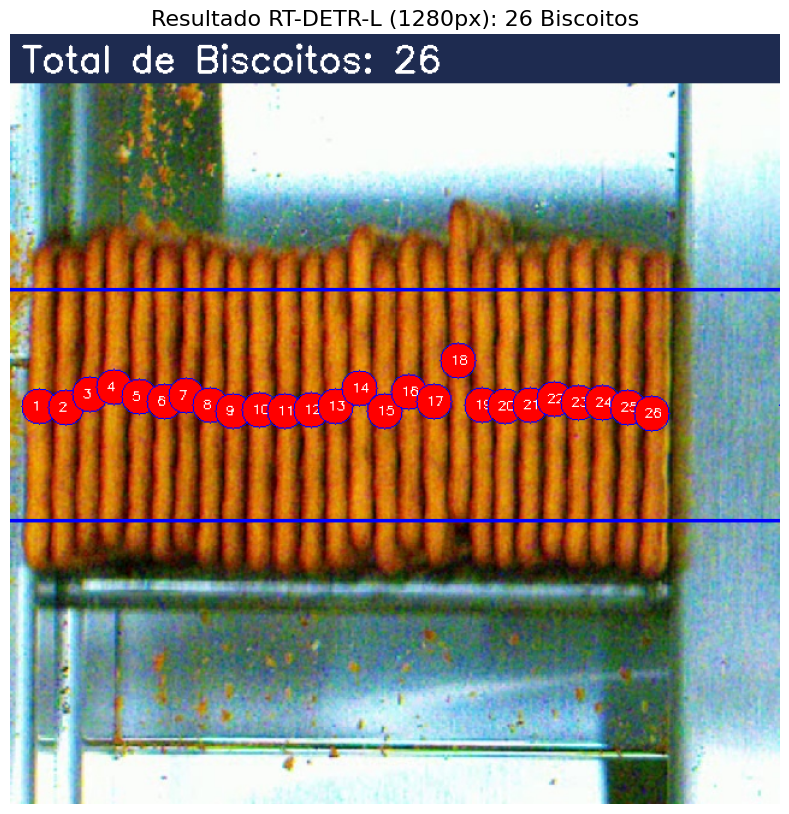

Contagem final na esteira: 26

image 1/1 D:\Arquivos\ProjetosPython\PICOS\data\outputs\teste_20260106_1280_novo_5\SM\SM_14_esquerdo__20260106_224928.jpg: 1280x1280 52 Biscoitos, 364.1ms
Speed: 6.7ms preprocess, 364.1ms inference, 0.8ms postprocess per image at shape (1, 3, 1280, 1280)

--- Relatório de Detecção (1280px | IoU: 0.1) ---
Biscoito 1: Score: 0.13 | Caixa: [0, 543, 20, 635] | Centro: [10, 589]
Biscoito 2: Score: 0.11 | Caixa: [0, 6, 17, 439] | Centro: [8, 222]
Biscoito 3: Score: 0.15 | Caixa: [0, 163, 14, 437] | Centro: [7, 300]
Biscoito 4: Score: 0.16 | Caixa: [0, 0, 14, 76] | Centro: [7, 38]
Biscoito 5: Score: 0.12 | Caixa: [0, 9, 16, 437] | Centro: [8, 223]
Biscoito 6: Score: 0.23 | Caixa: [11, 175, 39, 442] | Centro: [25, 308]
Biscoito 7: Score: 0.86 | Caixa: [12, 175, 36, 443] | Centro: [24, 309]
Biscoito 8: Score: 0.86 | Caixa: [34, 178, 58, 443] | Centro: [46, 310]
Biscoito 9: Score: 0.86 | Caixa: [54, 164, 78, 434] | Centro: [66, 299]
Biscoito 10: Score: 0.21 | Caixa

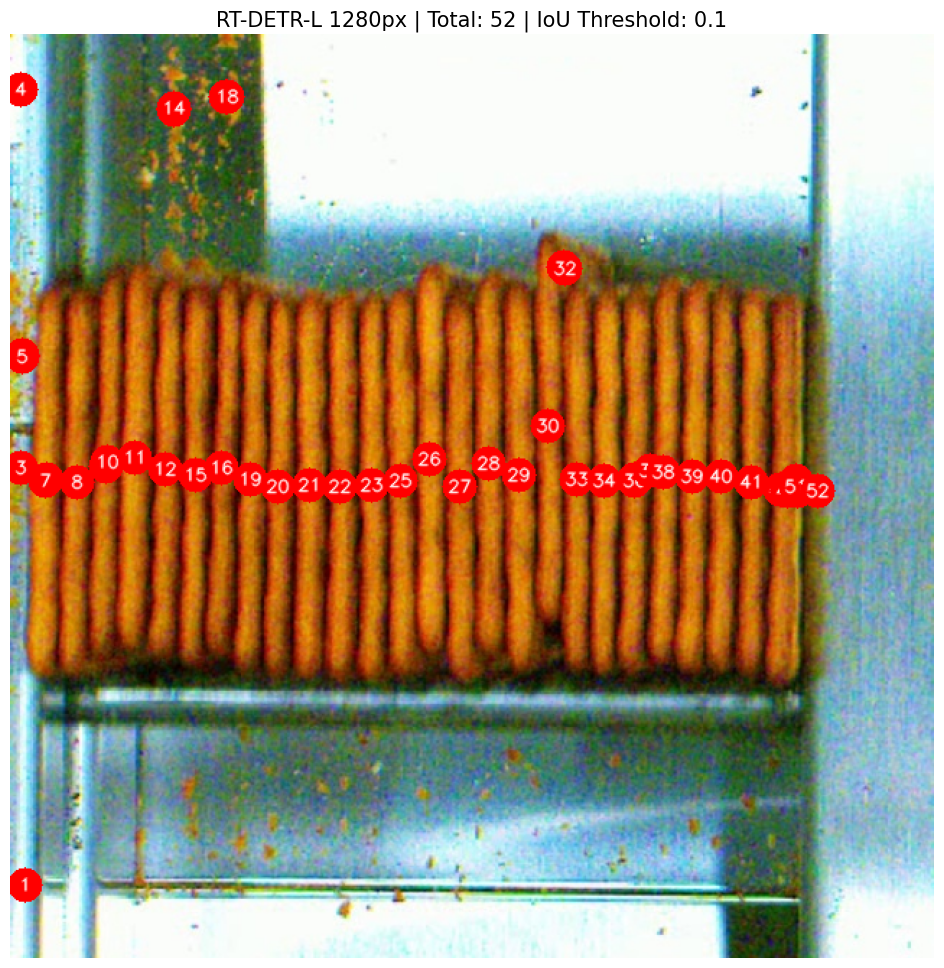

In [80]:

caminho_pesos = r"D:\Arquivos\ProjetosPython\PICOS\data\inputs\ia_models\RTDETR\best_1280_x.pt"
caminho_imagem = r"D:\Arquivos\ProjetosPython\PICOS\data\outputs\teste_20260106_1280_novo_5\SM\SM_14_esquerdo__20260106_224928.jpg" # 39

modelo_treinado = RTDETR(caminho_pesos)
imagem_array = cv2.imread(caminho_imagem)

total = run_model_1280(
    device='cuda', 
    model=modelo_treinado, 
    frame=imagem_array,
    limit_center= 15
)
print(f"Contagem final na esteira: {total}")

total = testar_modelo_centros_1280(caminho_imagem, caminho_pesos)
